# Paper plots / experiment tracker

Live figures from the experiment logs (see `paper/PLAN.md`, `paper/e1_coverage_fill.md`).
Baselines are **AdamW + iMuon only**. Each panel: AdamW vs Polar-LoRA (ours) vs iMuon,
Δ vs AdamW in σ-units. Renders partially as runs land (`allow_partial=True`). One plot per
cell. Re-run top-to-bottom to refresh.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'lora_playground').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.plotting import compare_variants_figure
from lora_playground.loader import load_runs

# Baselines + protagonist. AdamW MUST be a variant to render (target_label only annotates
# an already-loaded variant, it does not auto-load).
ADAMW = {'optimizer': 'adamw'}
PROTO = {'optimizer': 'diag-shampoo-polar-lora', 'cw_nesterov': True, 'polar_method': 'polar_express'}
IMUON = {'optimizer': 'imuon-lora'}
SIGMA = 0.0017  # AdamW noise-floor proxy

# The 8-cell E1 set (paper/e1_coverage_fill.md). data_key = substring matched on data_dir.
CELLS = [
    ('OLMo-2-1B opc r256',         'allenai/OLMo-2-0425-1B',     'opc',      256),
    ('Qwen2.5-1.5B opc r256',      'Qwen/Qwen2.5-1.5B',          'opc',      256),
    ('Llama-3.2-1B opc r256',      'meta-llama/Llama-3.2-1B',    'opc',      256),
    ('Llama-3-8B opc r256',        'meta-llama/Meta-Llama-3-8B', 'opc',      256),
    ('Qwen2.5-1.5B bengali r256',  'Qwen/Qwen2.5-1.5B',          'bengali',  256),
    ('Llama-3.2-1B openmath r64',  'meta-llama/Llama-3.2-1B',    'openmath',  64),
    ('Llama-3.2-1B openmath r128', 'meta-llama/Llama-3.2-1B',    'openmath', 128),
    ('Llama-3.2-1B openmath r256', 'meta-llama/Llama-3.2-1B',    'openmath', 256),
]

def panel(name, model, key, rank):
    """AdamW vs Polar-LoRA (ours) vs iMuon at one cell; Δ vs AdamW in σ-units."""
    common = dict(model_name=model, lora_r=rank, data_dir=(lambda d, k=key: k in str(d)))
    fig, _tdf, sdf = compare_variants_figure(
        {'AdamW': ADAMW, 'Polar-LoRA (ours)': PROTO, 'iMuon': IMUON},
        common_where=common, ref_label='AdamW',
        logs_root=str(ROOT / 'logs'), sigma_ref=SIGMA, max_steps=9000,
        allow_partial=True, allow_custom_labels=True, target_label='AdamW',
        suptitle=name,
    )
    plt.show()
    return sdf

## Coverage status (live)
Distinct lrs present per (cell, optimizer).

In [2]:
def _cfg(r):
    return r[0].get('_cli_args', r[0])

def _slug(c, key):
    return key in (str(c.get('data_dir', '')) + str(c.get('train_file', ''))).lower()

_cache = {opt: [ _cfg(x) for x in load_runs(where={'optimizer': opt}, warn_cross_commit=False) ]
          for opt in ('diag-shampoo-polar-lora', 'imuon-lora', 'adamw')}

def _nlrs(opt, model, key, rank, proto=False):
    lrs = set()
    for c in _cache[opt]:
        if c.get('model_name') == model and c.get('lora_r') == rank and _slug(c, key):
            if proto and not (c.get('cw_nesterov') and c.get('polar_method') == 'polar_express'):
                continue
            lrs.add(c.get('lr'))
    return len(lrs)

print(f"{'cell':28} | proto | iMuon | AdamW")
print('-' * 52)
for name, model, key, rank in CELLS:
    print(f"{name:28} | {_nlrs('diag-shampoo-polar-lora', model, key, rank, True):5d} | "
          f"{_nlrs('imuon-lora', model, key, rank):5d} | {_nlrs('adamw', model, key, rank):5d}")

cell                         | proto | iMuon | AdamW
----------------------------------------------------
OLMo-2-1B opc r256           |     3 |     0 |     5
Qwen2.5-1.5B opc r256        |     0 |     0 |     5
Llama-3.2-1B opc r256        |     0 |     0 |     5
Llama-3-8B opc r256          |     0 |     0 |     4
Qwen2.5-1.5B bengali r256    |     0 |     0 |     5
Llama-3.2-1B openmath r64    |     0 |     0 |     4
Llama-3.2-1B openmath r128   |     0 |     0 |     0
Llama-3.2-1B openmath r256   |     0 |     0 |     4


## Per-cell panels — AdamW vs Polar-LoRA (ours) vs iMuon

### 1. OLMo-2-1B opc r256

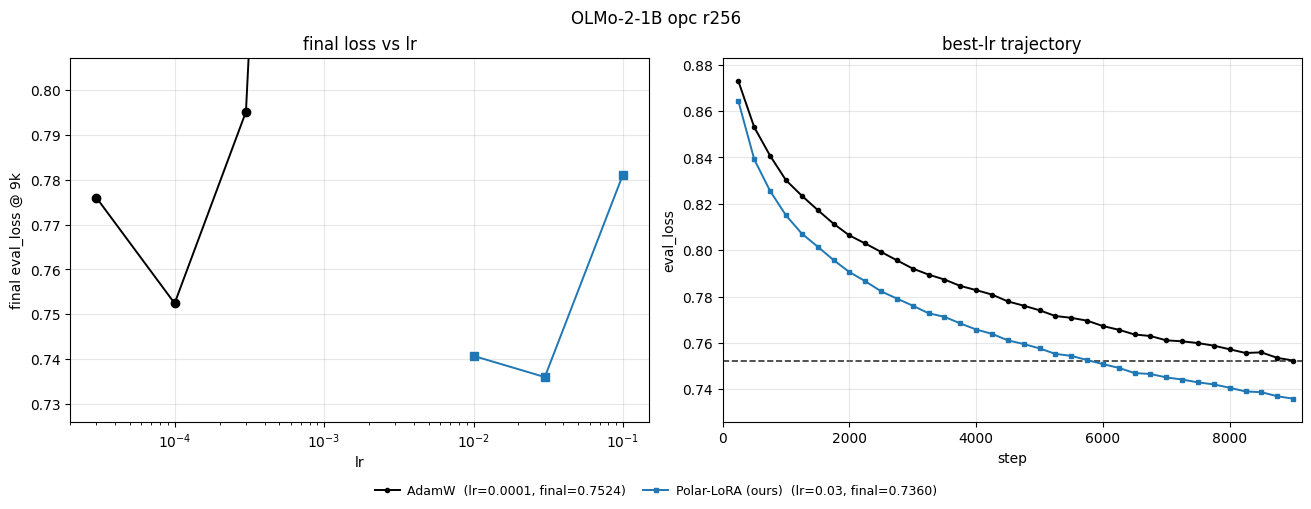

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.752439,NaN,NaN
1,Polar-LoRA (ours),0.0300,0.735985,-0.016454,-9.678906


In [3]:
panel('OLMo-2-1B opc r256', 'allenai/OLMo-2-0425-1B', 'opc', 256)

### 2. Qwen2.5-1.5B opc r256

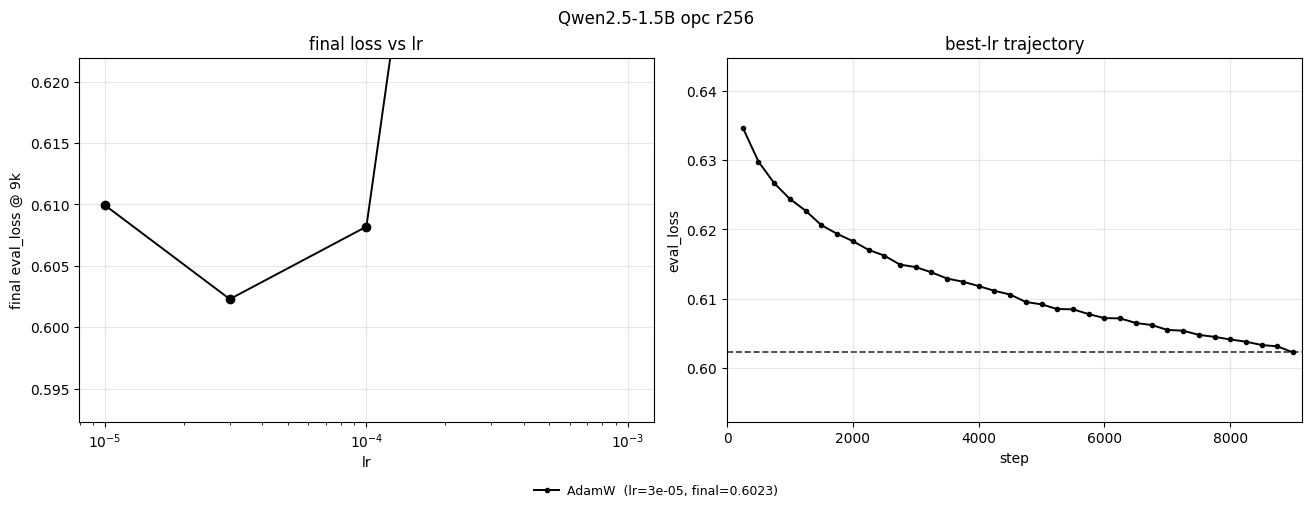

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.602292,None,None


In [4]:
panel('Qwen2.5-1.5B opc r256', 'Qwen/Qwen2.5-1.5B', 'opc', 256)

### 3. Llama-3.2-1B opc r256

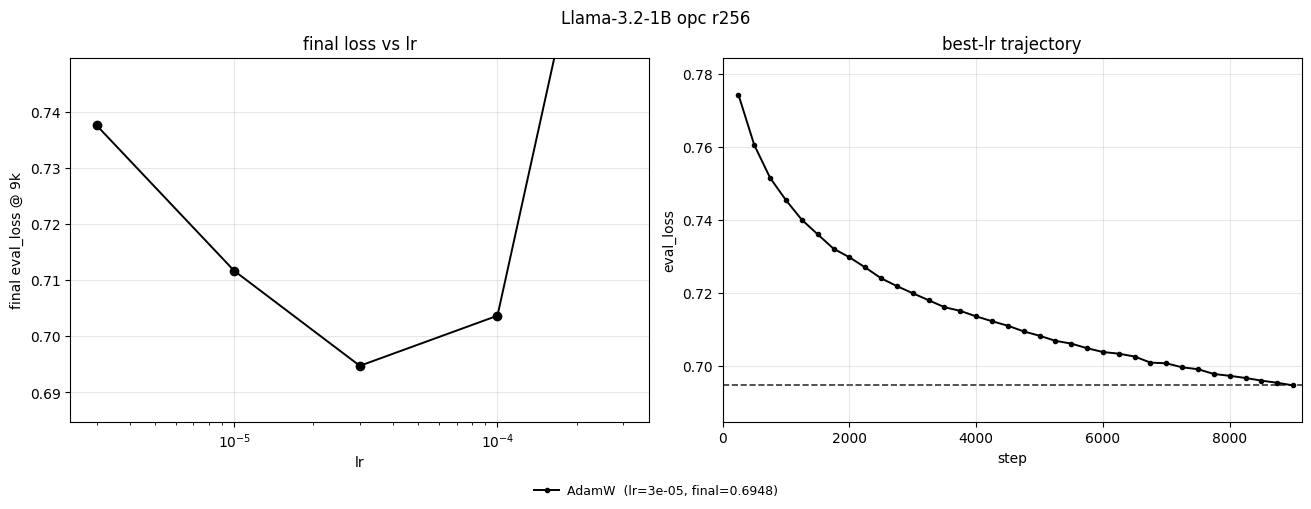

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.694754,None,None


In [5]:
panel('Llama-3.2-1B opc r256', 'meta-llama/Llama-3.2-1B', 'opc', 256)

### 4. Llama-3-8B opc r256

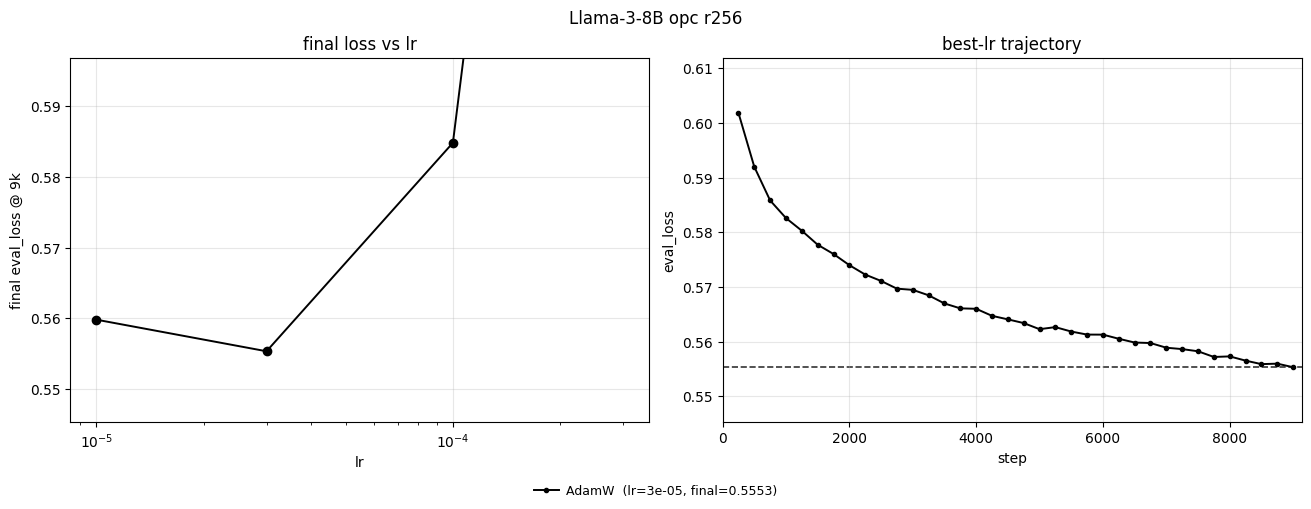

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.555303,None,None


In [6]:
panel('Llama-3-8B opc r256', 'meta-llama/Meta-Llama-3-8B', 'opc', 256)

### 5. Qwen2.5-1.5B bengali r256  (OOD pair vs cell 2)

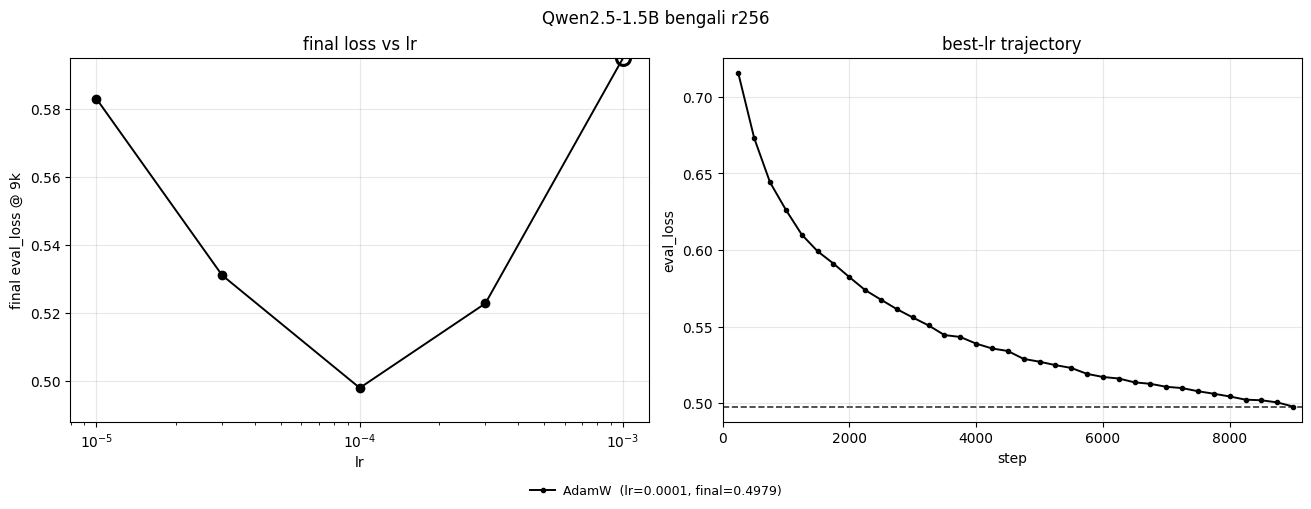

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.497858,None,None


In [7]:
panel('Qwen2.5-1.5B bengali r256', 'Qwen/Qwen2.5-1.5B', 'bengali', 256)

### 6. Llama-3.2-1B openmath r64  (rank ladder)

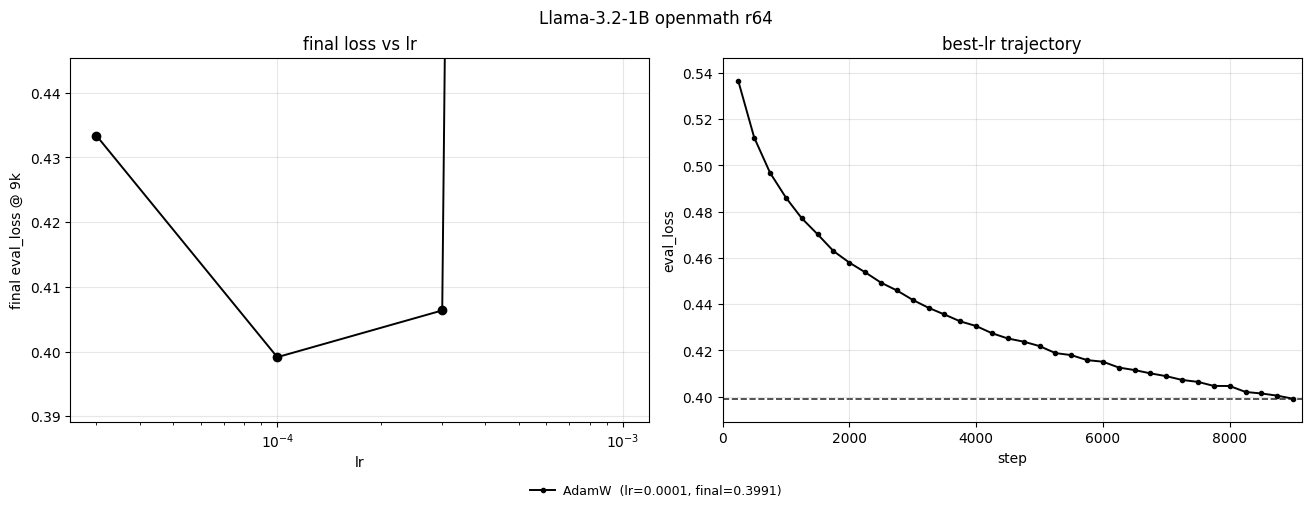

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.399128,None,None


In [8]:
panel('Llama-3.2-1B openmath r64', 'meta-llama/Llama-3.2-1B', 'openmath', 64)

### 7. Llama-3.2-1B openmath r128  (rank ladder)

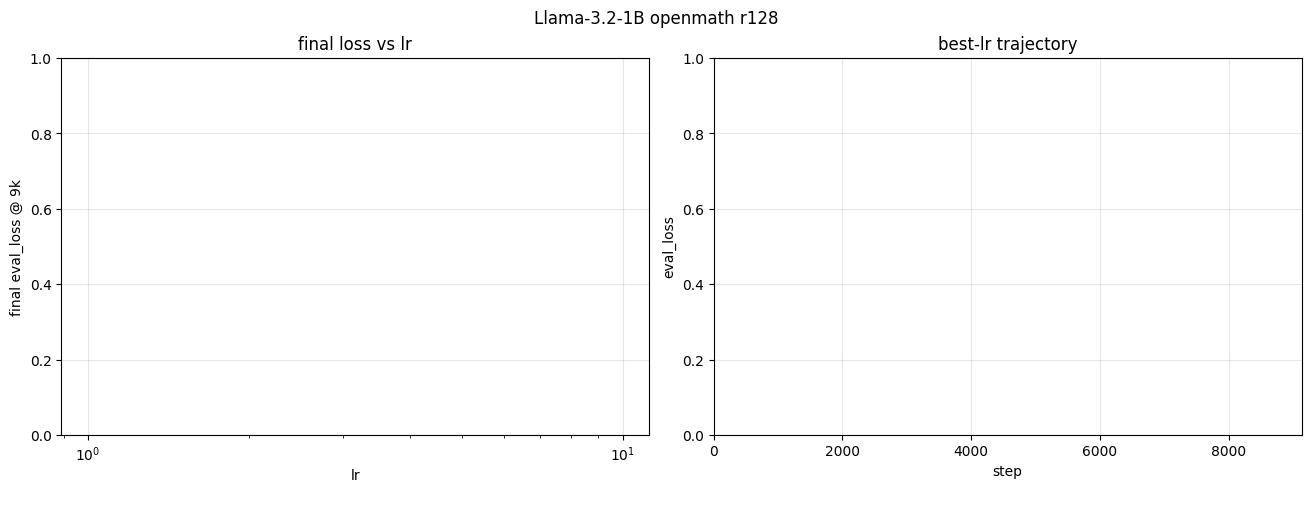

""


In [9]:
panel('Llama-3.2-1B openmath r128', 'meta-llama/Llama-3.2-1B', 'openmath', 128)

### 8. Llama-3.2-1B openmath r256  (rank ladder)

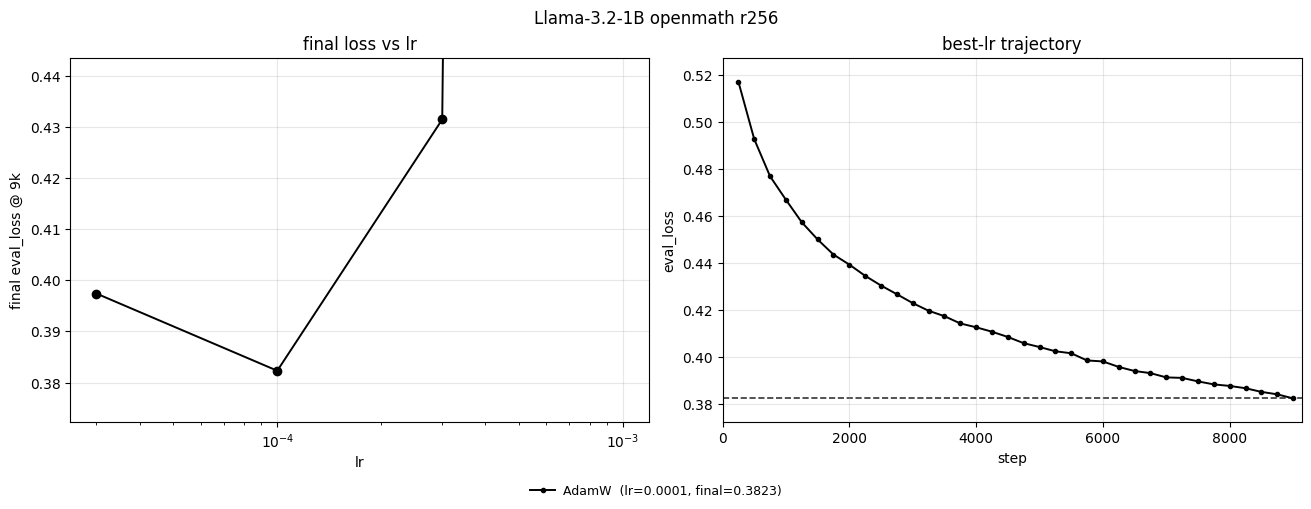

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.382301,None,None


In [10]:
panel('Llama-3.2-1B openmath r256', 'meta-llama/Llama-3.2-1B', 'openmath', 256)